# Revenue Leakage Analysis

## Problem Statement
The business is generating revenue but is experiencing instability in growth. There is a need to identify where revenue is being lost across the customer journey, operations, and seller performance.

## Objective

The objective of this project is to identify and quantify **revenue leakage** in an e-commerce business by analyzing customer behavior, delivery experience, and operational performance.

The analysis focuses on:
- customer retention and repeat purchasing behavior
- experience-driven revenue loss due to delivery delays
- operational leakage from cancellations and seller performance

The goal is to estimate revenue loss, identify major leakage sources, and highlight priority areas for business action.

## Dataset Overview

This analysis uses the Olist e-commerce dataset, which includes customer orders, payments, delivery timelines, reviews, sellers, and products.

Data is assumed to be appropriate for analysis.

## Assumptions
1. All monetary values in the analysis are assumed to be in `Indian Rupees (₹)`.
2. Revenue is considered only from orders with `order_status = 'delivered'`, as only delivered orders generate realized revenue.
3. Customers are classified as one-time or repeat based on the count of orders placed, regardless of order success or failure.
4. Revenue calculations are derived directly from `payments.payment_value` without accounting for refunds, discounts, or chargebacks.
5. In seller and operational analysis, delivery responsibility is assumed to lie with sellers or internal operations, as no delivery partner data is available.

## Analysis Structure

The revenue leakage analysis is conducted in three stages:
1. Customer Behavior Analysis
2. Experience-Driven Leakage
3. Operational & Seller-Side Leakage

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3

import warnings
warnings.filterwarnings('ignore')

In [2]:
conn = sqlite3.connect('olist.db')

## Data Overview
Following step are performed:

1. Database Inspection
2. Missing Value Analysis
3. Duplicate Record Validation
4. Referential Integrity Checks
5. Value and Range Validation
6. Revenue Consistency Validation

In [3]:
tables = pd.read_sql('''SELECT name FROM sqlite_master WHERE type = "table"''', conn)
tables

,name
0,customers
1,location
2,order_items
3,payments
4,reviews
5,orders
6,product
7,seller
8,product_category


In [4]:
# Checking row_count for each table (to confirm if all csv(s) loaded correctly)
for t in tables['name']:
    print(f"\nTable: {t}\n")
    display(pd.read_sql(f'''SELECT COUNT(*) FROM {t} LIMIT 5;''', conn))


Table: customers



,COUNT(*)
0,99441



Table: location



,COUNT(*)
0,1000163



Table: order_items



...

,COUNT(*)
0,32951



Table: seller



,COUNT(*)
0,3095



Table: product_category



,COUNT(*)
0,71


In [5]:
# column names for each table
for t in tables['name']:
    print(f"\nTable: {t}\n")
    cols = pd.read_sql(f'''SELECT * FROM {t} LIMIT 0;''', conn)
    print(cols.columns)
    print("-"* 50)


Table: customers

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')
--------------------------------------------------

Table: location

Index(['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng',
       'geolocation_city', 'geolocation_state'],
      dtype='object')
--------------------------------------------------

Table: order_items

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')
--------------------------------------------------

Table: payments

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')
--------------------------------------------------

Table: reviews

Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answe

In [6]:
# preview data from each table (5 rows each)
for t in tables['name']:
    print(f"\nTable : {t}")
    display(pd.read_sql(f'''SELECT * FROM {t} LIMIT 5;''', conn))
    print("-"*50)


Table : customers


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


--------------------------------------------------

Table : location


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


--------------------------------------------------

Table : order_items


...

--------------------------------------------------

Table : seller


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


--------------------------------------------------

Table : product_category


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


--------------------------------------------------


In [7]:
#checking for missing values
for table in tables['name']:
    
    # get column names
    cols = pd.read_sql(f"PRAGMA table_info({table})", conn)["name"].tolist()
    
    # build missing value query
    query = "SELECT " + ", ".join(
        [f"SUM(CASE WHEN {col} IS NULL THEN 1 ELSE 0 END) AS {col}" for col in cols]
    ) + f" FROM {table}"
    
    result = pd.read_sql(query, conn)
    
    print(f"\nMissing values in {table}")
    display(result.transpose())


Missing values in customers


,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0



Missing values in location


,0
geolocation_zip_code_prefix,0
geolocation_lat,0
geolocation_lng,0
geolocation_city,0
geolocation_state,0



Missing values in order_items


...

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2



Missing values in seller


,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0



Missing values in product_category


,0
product_category_name,0
product_category_name_english,0


There are missing values in `orders` and `reveiws` and `product` table BUT we will handle them while analysis. We will not handle them through generic approaches.

In [8]:
# Duplicate Checking

duplicate_checks = {
    "customers": ["customer_id"],
    "orders": ["order_id"],
    "seller": ["seller_id"],
    "product": ["product_id"]
} # checking for main files only as they derive others

for table, cols in duplicate_checks.items():
    
    col_string = ", ".join(cols)
    
    query = f"""
    SELECT {col_string}, COUNT(*) as count
    FROM {table}
    GROUP BY {col_string}
    HAVING COUNT(*) > 1
    """
    
    result = pd.read_sql(query, conn)
    
    print(f"\nDuplicates in {table}")
    display(result)


Duplicates in customers


,customer_id,count



Duplicates in orders


,order_id,count



Duplicates in seller


,seller_id,count



Duplicates in product


,product_id,count


No duplicates found! Means they maintain unique records. </br>
(*Used "customer_id" instead of "customer_unique_id" because unique customers shares multiple id at order level*)

**Referential Integrity Checking** </br>
*Checking mismached columns as they can distort revenue calculations*

In [9]:
# Payments without Orders
pd.read_sql("""SELECT COUNT(*) AS orphan_payments 
                FROM payments p
                LEFT JOIN orders o
                ON p.order_id = o.order_id
                WHERE o.order_id IS NULL
""", conn)

,orphan_payments
0,0


In [10]:
# Orders without Customers
pd.read_sql(""" SELECT COUNT(*) AS orphan_orders
                FROM orders o
                LEFT JOIN customers c
                ON o.customer_id = c.customer_id
                WHERE c.customer_id IS NULL
""", conn)

,orphan_orders
0,0


In [11]:
# Order Items without Orders
pd.read_sql(""" SELECT COUNT(*) AS orphan_order_items
                FROM order_items oi
                LEFT JOIN orders o
                ON oi.order_id = o.order_id
                WHERE o.order_id IS NULL
""", conn)

,orphan_order_items
0,0


In [12]:
# Order Items without Products
pd.read_sql(""" SELECT COUNT(*) AS orphan_products
                FROM order_items oi
                LEFT JOIN product p
                ON oi.product_id = p.product_id
                WHERE p.product_id IS NULL
""", conn)

,orphan_products
0,0


In [13]:
# Order Items without Sellers
pd.read_sql(""" SELECT COUNT(*) AS orphan_sellers
                FROM order_items oi
                LEFT JOIN seller s
                ON oi.seller_id = s.seller_id
                WHERE s.seller_id IS NULL
""", conn)

,orphan_sellers
0,0


In [14]:
# Payment Validaty Checking
pd.read_sql(""" SELECT COUNT(*) AS negative_payments
                FROM payments
                WHERE payment_value < 0
""", conn)

,negative_payments
0,0


In [15]:
pd.read_sql(""" SELECT COUNT(*) AS zero_payments
                FROM payments
                WHERE payment_value = 0
""", conn)

,zero_payments
0,9


In [16]:
pd.read_sql(""" SELECT payment_type, COUNT(*) AS count
                FROM payments
                WHERE payment_value = 0
                GROUP BY payment_type
""", conn)

,payment_type,count
0,not_defined,3
1,voucher,6


A small number of payment (9) have zero payment values, primarily associated with voucher based transactions or undefined payment type. Given very low frequency, these records are unlikely to affect revenue analysis.

In [17]:
# Checking Negetive Product Prices
pd.read_sql(""" SELECT COUNT(*) AS negative_prices
                FROM order_items
                WHERE price < 0
""", conn)

,negative_prices
0,0


In [18]:
# Checking Freight Anomalies
pd.read_sql(""" SELECT MIN(freight_value) AS min_freight,
                MAX(freight_value) AS max_freight
                FROM order_items
""", conn)

,min_freight,max_freight
0,0.0,409.68


In [19]:
# Order Status Distribution
pd.read_sql(""" SELECT order_status, COUNT(*) AS order_count
                FROM orders
                GROUP BY order_status
""", conn)

,order_status,order_count
0,approved,2
1,canceled,625
2,created,5
3,delivered,96478
4,invoiced,314
5,processing,301
6,shipped,1107
7,unavailable,609


Cancelled orders are one of the biggest revenue leakage sources.

In [20]:
# Valid Payment Methods
pd.read_sql(""" SELECT payment_type, COUNT(*) AS transactions
                FROM payments
                GROUP BY payment_type
""", conn)

,payment_type,transactions
0,boleto,19784
1,credit_card,76795
2,debit_card,1529
3,not_defined,3
4,voucher,5775


In [21]:
# Checking Revenue Consistency between Order value & payment value

pd.read_sql("""
WITH order_totals AS (
    SELECT order_id, SUM(price + freight_value) AS order_value
    FROM order_items
    GROUP BY order_id
),

payment_totals AS (
    SELECT order_id, SUM(payment_value) AS payment_value
    FROM payments
    GROUP BY order_id
)

SELECT o.order_id, ot.order_value, pt.payment_value
FROM orders o LEFT JOIN order_totals ot
ON o.order_id = ot.order_id
LEFT JOIN payment_totals pt
ON o.order_id = pt.order_id
WHERE ROUND(ot.order_value, 2) != ROUND(pt.payment_value, 2)
LIMIT 20
""", conn)

,order_id,order_value,payment_value
0,f04bfdbef5359607d39e66fccc9cc0de,998.50,998.49
1,8adafb3466daa5395694d3a906ff9d40,218.02,218.00
2,d5211af24819d319c02a285e7bb51750,186.75,186.76
3,bb2e64c3040ceb9b7ca2bfc602adca08,257.36,257.34
4,84d6d9710c8af32b5e88f2d1c14ab871,57.68,61.70
5,74016effecaa79d592487f6a4ee47d4b,51.51,56.96
6,239f380355f65dcb68551f07d16fc4a8,222.63,251.63
7,4c57f545143e8865ca2347d8cba154a7,139.61,151.01
8,6e57e23ecac1ae881286657694444267,350.41,333.91
9,b38b3526b8b8fdc807e8a0a42ab78573,30.06,30.19


In [22]:
pd.read_sql("""
SELECT *
FROM payments
WHERE order_id = '84d6d9710c8af32b5e88f2d1c14ab871'
""", conn)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,84d6d9710c8af32b5e88f2d1c14ab871,1,credit_card,5,61.7


In [23]:
pd.read_sql("""
SELECT *
FROM order_items
WHERE order_id = '84d6d9710c8af32b5e88f2d1c14ab871'
""", conn)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,84d6d9710c8af32b5e88f2d1c14ab871,1,61e2cc02b96d5d61c27e21754260dccd,b2ba3715d723d245138f291a6fe42594,2018-01-31 22:35:25,49.9,7.78


A small subset of orders show differences between aggregated order value (price + freight_value) and recorded payments. These differences are likely caused by installment based payments, voucher combinations, or payment processing adjustments rather than direct data inconsistencies.

## Leakage Analysis

### 01: Customer Behavior
Understand how `customer's purchase behavior` causes revenue leakage, and quantify how big that leakage is in terms of:
- number of customers
- revenue involved

In [24]:
# One-time vs Repeat Customers
pd.read_sql(''' SELECT c.customer_unique_id, COUNT(DISTINCT o.order_id) AS order_count
                FROM orders o JOIN customers c
                ON o.customer_id = c.customer_id
                WHERE o.order_status = "delivered"
                GROUP BY 1;
                ''', conn)

,customer_unique_id,order_count
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1
...,...,...
93353,fffcf5a5ff07b0908bd4e2dbc735a684,1
93354,fffea47cd6d3cc0a88bd621562a9d061,1
93355,ffff371b4d645b6ecea244b27531430a,1
93356,ffff5962728ec6157033ef9805bacc48,1


In [25]:
# Customer Classification into One-time and Repeat
query = '''
WITH customer_orders AS (
    SELECT c.customer_unique_id, COUNT(DISTINCT o.order_id) AS order_count
    FROM orders o JOIN customers c
    ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
)
SELECT CASE WHEN order_count = 1 THEN 'One-time' 
            ELSE 'Repeat' END AS customer_type,
       COUNT(*) AS customer_count
FROM customer_orders
GROUP BY customer_type;'''

order_freq = pd.read_sql(query, conn)
order_freq

,customer_type,customer_count
0,One-time,90557
1,Repeat,2801


In [26]:
((order_freq['customer_count'] / order_freq['customer_count'].sum()) * 100).round(2)

0    97.0
1     3.0
Name: customer_count, dtype: float64

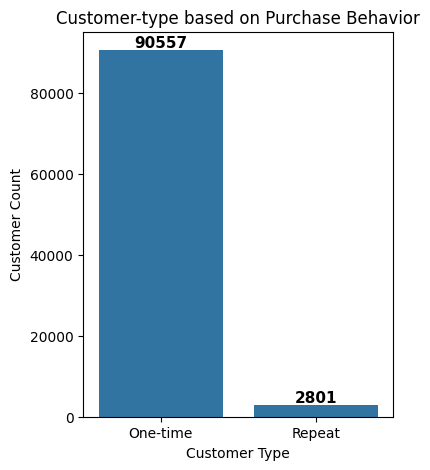

In [27]:
plt.figure(figsize = (4,5))
ax = sns.barplot(x = "customer_type", y = "customer_count", data = order_freq)
ax.bar_label(ax.containers[0], color='k', fontsize=11, fontweight='bold')

plt.xlabel("Customer Type")
plt.ylabel("Customer Count")
plt.title("Customer-type based on Purchase Behavior")
plt.show()

In [28]:
# Revenue by Customer-Type
query = '''
WITH customer_orders AS (
    SELECT c.customer_unique_id, COUNT(DISTINCT o.order_id) AS order_count
    FROM orders o JOIN customers c
    ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id 
    ),

customer_revenue AS (
    SELECT c.customer_unique_id, SUM(p.payment_value) AS revenue
    FROM orders o JOIN customers c
    ON o.customer_id = c.customer_id
    JOIN payments p 
    ON o.order_id = p.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
    )
    
SELECT CASE WHEN co.order_count = 1 THEN 'One-time'
            ELSE 'Repeat' END AS customer_type,
       SUM(cr.revenue) AS total_revenue
FROM customer_orders co JOIN customer_revenue cr
ON co.customer_unique_id = cr.customer_unique_id
GROUP BY customer_type;
'''
revenue_per_type = pd.read_sql(query, conn)
revenue_per_type

,customer_type,total_revenue
0,One-time,14558104.56
1,Repeat,864357.21


In [29]:
revenue_per_type['revenue_perc'] = ((revenue_per_type['total_revenue'] / revenue_per_type['total_revenue'].sum())* 100).round(2)
revenue_per_type['revenue_perc']

0    94.4
1     5.6
Name: revenue_perc, dtype: float64

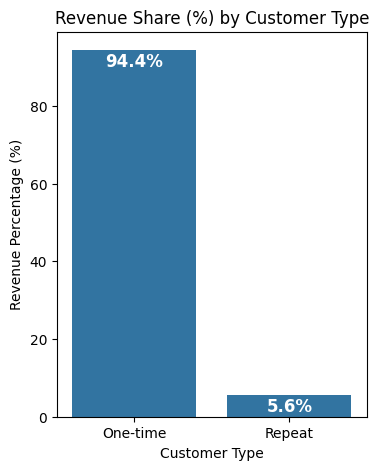

In [30]:
plt.figure(figsize = (4,5))
ax = sns.barplot(data = revenue_per_type, x = 'customer_type', y = 'revenue_perc')
ax.bar_label(ax.containers[0], color='w', fontsize=12, fontweight='bold', padding = -15, fmt='%.1f%%')
plt.xlabel("Customer Type")
plt.ylabel("Revenue Percentage (%)")
plt.title("Revenue Share (%) by Customer Type")
plt.show()

In [31]:
# Average Revenue per Customer (ARPC)
query = '''
WITH customer_orders AS (
    SELECT  c.customer_unique_id, 
            COUNT(DISTINCT o.order_id) AS order_count
    FROM orders o JOIN customers c
    ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
),

customer_revenue AS (
    SELECT  c.customer_unique_id, 
            SUM(p.payment_value) AS revenue
    FROM orders o JOIN customers c
    ON o.customer_id = c.customer_id
    JOIN payments p 
    ON o.order_id = p.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
    )

SELECT CASE WHEN co.order_count = 1 THEN 'One-time' 
            ELSE 'Repeat' END AS customer_type,
       COUNT(*) AS customer_count,
       SUM(cr.revenue) AS total_revenue
FROM customer_orders co JOIN customer_revenue cr
ON co.customer_unique_id = cr.customer_unique_id
GROUP BY customer_type;
'''

revenue_customer = pd.read_sql(query, conn)
revenue_customer

,customer_type,customer_count,total_revenue
0,One-time,90556,14558104.56
1,Repeat,2801,864357.21


In [32]:
revenue_customer['avg_revenue'] = (revenue_customer['total_revenue'] / revenue_customer['customer_count']).round(2)
revenue_customer

,customer_type,customer_count,total_revenue,avg_revenue
0,One-time,90556,14558104.56,160.76
1,Repeat,2801,864357.21,308.59


In [33]:
print("Ratio of average revenue per customer:",
      (revenue_customer['avg_revenue'].iloc[1] / revenue_customer['avg_revenue'].iloc[0]).round(2))

Ratio of average revenue per customer: 1.92


### Insight

- `97%` of customers are one-time buyers contributing `94.4%` of total revenue (`around 14.5M`).

- Repeat customers generate `nearly 2× higher` average revenue per customer compared to one-time buyers.

### What This Means

- Revenue is heavily dependent on single purchases rather than customer retention.

- Despite being a small segment, repeat customers show significantly higher value, indicating strong monetization potential.

The extremely low repeat rate suggests lost lifetime value and **clear revenue leakage** caused by **poor retention strategy.**

### 02: Experience-Driven Leakage
We will check:
- How many customers face bad experience (`late delivery` OR `low review`)
- How much revenue is associated with them

In [34]:
# Delivery delay identification
query = '''SELECT count(*) AS total_orders, 
                  SUM(CASE WHEN order_estimated_delivery_date < order_delivered_customer_date THEN 1 ELSE 0 END) AS late_delivery
           FROM orders
           WHERE order_status = "delivered";
           '''
late_orders = pd.read_sql(query, conn)
late_orders

,total_orders,late_delivery
0,96478,7826


In [35]:
print("Percentage of total orders that were late:", 
      float((late_orders['late_delivery'] / late_orders['total_orders'] * 100).round(2)), "%"
)

Percentage of total orders that were late: 8.11 %


In [36]:
# Customer impact of delivery delays
query = '''
SELECT COUNT(DISTINCT c.customer_unique_id) AS total_customers, 
       COUNT(DISTINCT CASE WHEN o.order_estimated_delivery_date < o.order_delivered_customer_date 
       THEN c.customer_unique_id END) AS affected_customers
FROM customers c JOIN orders o
ON c.customer_id = o.customer_id
WHERE o.order_status = "delivered";
'''
# (customers experienced at least one late delivery)
affected_customers = pd.read_sql(query, conn)
affected_customers

,total_customers,affected_customers
0,93358,7771


In [37]:
print("Percentage of customers affected by late delivery:", 
      float((affected_customers['affected_customers'] / affected_customers['total_customers'] * 100).round(2)), "%"
)

Percentage of customers affected by late delivery: 8.32 %


In [38]:
# Revenue associated with delayed orders
query = '''
SELECT SUM(p.payment_value) AS total_revenue,
       SUM(CASE WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date THEN p.payment_value END) AS revenue_at_risk
FROM payments p JOIN orders o
ON p.order_id = o.order_id
WHERE o.order_status = "delivered";
'''
delay_revenue = pd.read_sql(query, conn)
delay_revenue

,total_revenue,revenue_at_risk
0,15422461.77,1351646.79


In [39]:
print("Percentage of total revenue linked to late delivered orders:", 
      float((delay_revenue['revenue_at_risk'] / delay_revenue['total_revenue'] * 100).round(2)), "%"
)

Percentage of total revenue linked to late delivered orders: 8.76 %


In [40]:
# reviews vs delivery experience
query = '''
SELECT ROUND(AVG(CASE WHEN (o.order_delivered_customer_date > o.order_estimated_delivery_date) THEN r.review_score END), 2) AS avg_late_rating,
       ROUND(AVG(CASE WHEN (o.order_delivered_customer_date <= o.order_estimated_delivery_date) THEN r.review_score END), 2) AS avg_ON_time_rating
FROM reviews r JOIN orders o
ON r.order_id = o.order_id
WHERE o.order_status = "delivered";
''' # AVG() ignores NULL values.
avg_rating = pd.read_sql(query, conn)
avg_rating

,avg_late_rating,avg_ON_time_rating
0,2.57,4.29


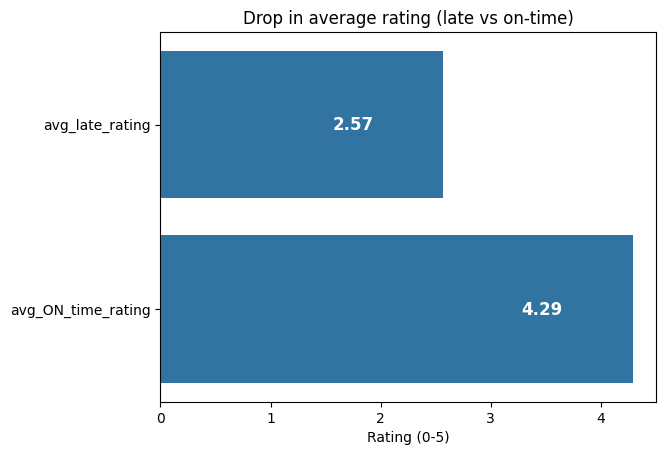

In [41]:
plt.figure()
ax = sns.barplot( x=avg_rating.iloc[0], y=avg_rating.columns, orient='h' )
ax.bar_label(ax.containers[0], padding=-80, color='white', fontsize=12, fontweight='bold')

plt.xlabel('Rating (0-5)')
plt.ylabel('')
plt.title("Drop in average rating (late vs on-time)")
plt.show()

In [42]:
print("Drop in average rating (late vs on-time):", 
      float((avg_rating['avg_ON_time_rating'] / avg_rating['avg_late_rating']).round(2))
)

Drop in average rating (late vs on-time): 1.67


In [43]:
# Experience & Customer return behaviour
query = '''
WITH bad_exp_customers AS (
    SELECT DISTINCT c.customer_unique_id AS id
    FROM customers c 
    JOIN orders o
    ON c.customer_id = o.customer_id
    JOIN reviews r 
    ON r.order_id = o.order_id
    WHERE (o.order_status = "delivered" AND (o.order_delivered_customer_date > o.order_estimated_delivery_date) 
        AND r.review_score <= 2)
), 
customers_order_count AS (
    SELECT b.id, COUNT(o.order_id) AS total_orders
    FROM bad_exp_customers b JOIN customers c
    ON b.id = c.customer_unique_id
    JOIN orders o
    ON o.customer_id = c.customer_id
    GROUP BY b.id
)

SELECT COUNT(*) AS total_customers, 
       SUM(CASE WHEN total_orders = 1 THEN 1 ELSE 0 END) AS one_time, 
       SUM(CASE WHEN total_orders > 1 THEN 1 ELSE 0 END) AS repeat
FROM customers_order_count;
'''

repeat_orders = pd.read_sql(query, conn)
repeat_orders

,total_customers,one_time,repeat
0,4121,3933,188


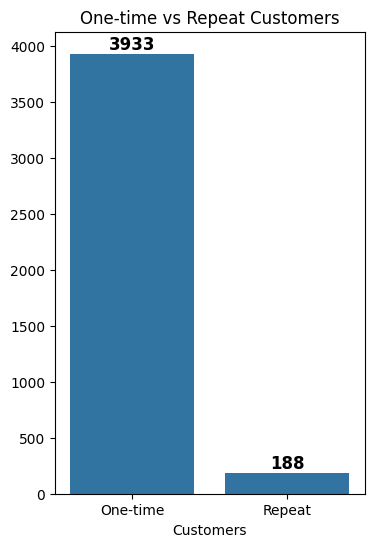

In [44]:
plt.figure(figsize = (4,6))
ax = sns.barplot(y=repeat_orders[['one_time', 'repeat']].iloc[0], x=['One-time', 'Repeat'])

ax.bar_label(ax.containers[0], fontsize=12, fontweight='bold')

plt.xlabel('Customers')
plt.ylabel('')
plt.title('One-time vs Repeat Customers')
plt.show()

In [45]:
print("Repeat rate after late delivery:", 
      float((repeat_orders['repeat'] / repeat_orders['total_customers'] * 100).round(2)), "%"
)
print("Percentage of customers who never reordered after late delivery:", 
      float((repeat_orders['one_time'] / repeat_orders['total_customers'] * 100).round(2)), "%"
)

Repeat rate after late delivery: 4.56 %
Percentage of customers who never reordered after late delivery: 95.44 %


### Insights:
- `8.11%` of total orders were delivered late, affecting `8.32%` of customers
- `8.76%` of total revenue, worth `1.3M`, is linked to late deliveries
- Average customer rating drops by `1.67 points`, from 4.29 to 2.57, due to late delivery
- Only `4.56%` of customers reorder after a late delivery, while `95.44%` never return


### What this means:

Late delivery significantly impacts **customer satisfaction and repeat purchase behavior.** </br>
A substantial portion of revenue is linked to customers experiencing delayed deliveries, which drastically reduces their likelihood of returning.

This indicates **clear revenue leakage** caused by operational failures in delivery performance, **putting future revenue at risk**.

### 03: Operational  & Seller-Side Leakage
we will check where revenue is lost because the business or sellers failed to execute properly. </br>
This will include:
- orders that never got completed
- sellers (operational) causing delays or cancellations
- revenue that should have happened but didn’t


In [59]:
# Order Cancellation Leakage
query = '''SELECT COUNT(*) AS total_orders, SUM(CASE WHEN o.order_status = "canceled" THEN 1 ELSE 0 END) AS canceled_orders,
                  ROUND(100.0 * SUM(CASE WHEN order_status = "canceled" THEN 1 ELSE 0 END) / COUNT(*), 2) AS canceled_pct
           FROM orders o;
'''
pd.read_sql(query, conn)

,total_orders,canceled_orders,canceled_pct
0,99441,625,0.63


Joining orders with payments duplicates rows because a single order can have multiple payment records. Since cancellation analysis is performed at the order level, the correct approach is to use the orders table directly to avoid inflated counts.

In [60]:
query = '''SELECT SUM(CASE WHEN o.order_status = "canceled" THEN p.payment_value ELSE 0 END) AS canceled_revenue,
                  ROUND(100.0 * SUM(CASE WHEN o.order_status = "canceled" THEN p.payment_value ELSE 0 END) / SUM(p.payment_value), 2) AS canceled_pct
           FROM orders o JOIN payments p
           ON o.order_id = p.order_id;
'''
pd.read_sql(query, conn)

,canceled_revenue,canceled_pct
0,143255.6,0.89


In [47]:
# Seller-related delivery delays
query = '''
SELECT o2.seller_id, COUNT(o.order_id) AS delayed_orders
FROM order_items o2 JOIN orders o
ON o2.order_id = o.order_id
WHERE o.order_status = "delivered" 
AND o.order_delivered_customer_date > o.order_estimated_delivery_date
GROUP BY 1
ORDER BY 2 DESC
LIMIT 10;
'''
pd.read_sql(query, conn)

,seller_id,delayed_orders
0,4a3ca9315b744ce9f8e9374361493884,214
1,1f50f920176fa81dab994f9023523100,182
2,4869f7a5dfa277a7dca6462dcf3b52b2,133
3,1025f0e2d44d7041d6cf58b6550e0bfa,131
4,7c67e1448b00f6e969d365cea6b010ab,130
5,6560211a19b47992c3666cc44a7e94c0,124
6,ea8482cd71df3c1969d7b9473ff13abc,123
7,955fee9216a65b617aa5c0531780ce60,119
8,da8622b14eb17ae2831f4ac5b9dab84a,113
9,cc419e0650a3c5ba77189a1882b7556a,103


In [48]:
# Sellers causing frequent late-delivery
query = '''
WITH sellers AS (
SELECT oi.seller_id, COUNT(DISTINCT o.order_id) AS total_orders, 
       COUNT(DISTINCT CASE WHEN o.order_status = 'delivered' AND o.order_delivered_customer_date > o.order_estimated_delivery_date
       THEN o.order_id END) AS late_orders
FROM order_items oi
JOIN orders o
ON oi.order_id = o.order_id
GROUP BY oi.seller_id)

SELECT seller_id
FROM sellers
WHERE (late_orders >= 0.25 * total_orders) AND (late_orders >= 15);
'''
# assumed the threshold of bad performance as 25% of total_orders
# & minimum late deliveries should atleast 15
pd.read_sql(query, conn)

,seller_id
0,54965bbe3e4f07ae045b90b0b8541f52
1,a49928bcdf77c55c6d6e05e09a9b4ca5
2,beadbee30901a7f61d031b6b686095ad
3,ede0c03645598cdfc63ca8237acbe73d


In [49]:
# Revenue Impacted by Poor Seller Performance
query = '''
WITH seller_perfm AS (
    SELECT oi.seller_id, COUNT(DISTINCT o.order_id) AS total_orders,
        COUNT(DISTINCT CASE WHEN o.order_status = 'delivered'
             AND o.order_delivered_customer_date > o.order_estimated_delivery_date
        THEN o.order_id END) AS late_orders
    FROM order_items oi
    JOIN orders o
    ON oi.order_id = o.order_id
    GROUP BY oi.seller_id
),

bad_perfm_seller AS (
    SELECT seller_id
    FROM seller_perfm
    WHERE late_orders >= 0.25 * total_orders AND late_orders >= 15
),

late_orders AS (
    SELECT DISTINCT oi.order_id
    FROM order_items oi JOIN orders o ON oi.order_id = o.order_id
    JOIN bad_perfm_seller b
    ON oi.seller_id = b.seller_id
    WHERE o.order_status = 'delivered' AND o.order_delivered_customer_date > o.order_estimated_delivery_date
)

SELECT SUM(p.payment_value) AS total_revenue_at_risk
FROM late_orders lo JOIN payments p
ON lo.order_id = p.order_id;
'''
pd.read_sql(query, conn)

,total_revenue_at_risk
0,9108.42


In [50]:
# Seller Concentration Risk
query = '''
WITH seller_revenue AS ( 
            SELECT oi.seller_id, SUM(p.payment_value) AS seller_revenue
            FROM (SELECT DISTINCT order_id, seller_id
                  FROM order_items) oi JOIN payments p
            ON p.order_id = oi.order_id
            GROUP BY 1),
            
    top_seller AS (
            SELECT seller_id, seller_revenue
            FROM seller_revenue
            ORDER BY 2 DESC
            LIMIT 10
    )
    
SELECT ROUND((SUM(seller_revenue) / (SELECT SUM(payment_value) FROM payments))*100 , 3)AS top_10_sellers_contri_perc
FROM top_seller;
''' 
# TOP 10 sellers are assumed as top_sellers
top_contri = pd.read_sql(query, conn)
top_contri

,top_10_sellers_contri_perc
0,12.901


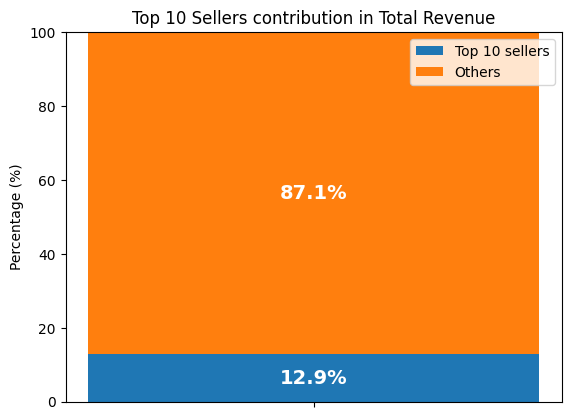

In [51]:
late_pct = top_contri.iloc[0, 0]
other_pct = 100 - late_pct

plt.figure()
plt.bar([''], late_pct, label='Top 10 sellers')
plt.bar([''], other_pct, bottom=late_pct, label='Others')

ax = plt.gca()
ax.bar_label(ax.containers[0], fmt='%.1f%%', label_type='center', color='white', fontweight='bold', fontsize = 14)
ax.bar_label(ax.containers[1], fmt='%.1f%%', label_type='center', color='white', fontweight='bold', fontsize = 14)

plt.ylim(0, 100)
plt.ylabel('Percentage (%)')
plt.title("Top 10 Sellers contribution in Total Revenue")
plt.legend()
plt.show()

### **Insights:** 
- `625 orders` were cancelled, representing `about 143K` in unrealized revenue.
- Only `4 sellers` are responsible for frequent late deliveries.
- The direct revenue exposure from poor seller performance is relatively small.
- Top sellers contribute only `12.9%` of total revenue.


**What this means:** </br>
Revenue leakage is driven mainly by operational failures like cancellations rather than seller dependency or seller concentration risk.


Clear evidence that primary **REVENUE LEAKAGE** is due to order cancellations, with operational delays being secondary.

## Key Findings
- Customer retention is the largest source of revenue leakage.
- Delivery delays directly reduce customer satisfaction and repeat purchases.
- Order cancellations result in direct and immediate revenue loss.
- Seller concentration risk is low, indicating diversified revenue sources.

## Recommendations
- Prioritize customer retention strategies for high-value repeat customers.
- Improve delivery reliability to reduce experience-driven churn.
- Investigate and reduce root causes of order cancellations.
- Monitor and improve the performance of sellers responsible for frequent delivery delays.

## Conclusion
The analysis indicates that revenue leakage is driven mainly by operational issues, not by seller concentration or customer demand. Most revenue loss comes from order cancellations, while delivery delays are limited to a small number of sellers and do not pose a major risk. 

Low customer retention also shows that many customers do not return after their first purchase, which limits long term revenue growth.

Overall, improving operational execution offers the clearest opportunity to stabilize and sustain revenue growth.